<a href="https://colab.research.google.com/github/Carmen10-171/07MIAR_Redes-Neuronales/blob/main/Practica_neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Practica -COVID19
Práctica completa con las funcionalidades que pide el PDF:
DataGenerator,
Autoencoder clásico,
Autoencoder variacional,
entrenamiento,
visualización
y evaluación mediante reconstrucción de imágenes RX.

## 1.- my_data_generator.py


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tensorflow.keras.utils import Sequence


class DataGenerator(Sequence):

    def __init__(
        self,
        csv_file,
        img_dir,
        partition='train',
        batch_size=16,
        dim=(128, 128),
        n_channels=1,
        shuffle=True
    ):

        self.df = pd.read_csv(csv_file, sep=';')
        self.df.columns = self.df.columns.str.strip()

        self.df = self.df[
            self.df['Partition'].astype(str).str.strip() == partition
        ]

        self.img_dir = img_dir
        self.batch_size = batch_size
        self.dim = dim
        self.n_channels = n_channels
        self.shuffle = shuffle

        self.indexes = np.arange(len(self.df))

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):

        indexes = self.indexes[
            index * self.batch_size:(index + 1) * self.batch_size
        ]

        batch_df = self.df.iloc[indexes]

        X = []

        for _, row in batch_df.iterrows():

            img_path = os.path.join(
                self.img_dir,
                str(row["ID"]).strip()
            )

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                raise FileNotFoundError(
                    f"No se encontró la imagen: {img_path}"
                )

            img = cv2.resize(img, self.dim)

            img = self.norm(img)

            img = np.expand_dims(img, axis=-1)

            X.append(img)

        X = np.array(X, dtype=np.float32)

        return X, X

    def on_epoch_end(self):

        self.indexes = np.arange(len(self.df))

        if self.shuffle:
            np.random.shuffle(self.indexes)

    def get_sample(self):

        idx = np.random.randint(0, len(self.df))

        row = self.df.iloc[idx]

        img_path = os.path.join(
            self.img_dir,
            str(row["ID"]).strip()
        )

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise FileNotFoundError(
                f"No se encontró la imagen: {img_path}"
            )

        img = cv2.resize(img, self.dim)

        img = self.norm(img)

        return img

    def norm(self, img):
        return img.astype(np.float32) / 255.0

### 2. convolutional_autoencoder.py

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Flatten,
    Dense,
    Reshape,
    Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K


class ConvAutoencoder:

    def __init__(self,
                 input_shape=(128, 128, 1),
                 latent_dim=128,
                 variational=False):

        self.input_shape = input_shape
        self.latent_dim = latent_dim
        self.variational = variational

        self.build()

    def sampling(self, args):

        z_mean, z_log_var = args

        epsilon = K.random_normal(
            shape=(K.shape(z_mean)[0], self.latent_dim)
        )

        return z_mean + K.exp(0.5 * z_log_var) * epsilon

    def build(self):

        inputs = Input(shape=self.input_shape)

        x = Conv2D(32, 3,
                   activation='relu',
                   padding='same')(inputs)

        x = MaxPooling2D(2, padding='same')(x)

        x = Conv2D(64, 3,
                   activation='relu',
                   padding='same')(x)

        x = MaxPooling2D(2, padding='same')(x)

        shape_before_flatten = K.int_shape(x)

        x = Flatten()(x)

        if self.variational:

            z_mean = Dense(self.latent_dim)(x)
            z_log_var = Dense(self.latent_dim)(x)

            z = Lambda(self.sampling)(
                [z_mean, z_log_var]
            )

            latent = z

        else:

            latent = Dense(
                self.latent_dim,
                activation='relu'
            )(x)

        x = Dense(
            np.prod(shape_before_flatten[1:])
        )(latent)

        x = Reshape(shape_before_flatten[1:])(x)

        x = Conv2D(
            64,
            3,
            activation='relu',
            padding='same'
        )(x)

        x = UpSampling2D(2)(x)

        x = Conv2D(
            32,
            3,
            activation='relu',
            padding='same'
        )(x)

        x = UpSampling2D(2)(x)

        outputs = Conv2D(
            1,
            3,
            activation='sigmoid',
            padding='same'
        )(x)

        self.model = Model(inputs, outputs)

        if self.variational:

            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(
                    inputs,
                    outputs
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)
            )

            self.model.add_loss(
                reconstruction_loss + kl_loss
            )

    def compile(self):

        self.model.compile(
            optimizer='adam',
            loss='binary_crossentropy'
        )

    def train_with_generator(
            self,
            train_gen,
            val_gen,
            epochs=50):

        return self.model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=epochs
        )

    def save_model(self, path):

        self.model.save(path)

    def load_model(self, path):

        self.model = tf.keras.models.load_model(
            path,
            compile=False
        )

### 3. training_CAE.ipynb


In [ ]:
from my_data_generator import DataGenerator
from convolutional_autoencoder import ConvAutoencoder
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'my_data_generator'

**Carga de datos**

In [ ]:
CSV_FILE = "partition.csv"
IMG_DIR = "images"

train_gen = DataGenerator(
    CSV_FILE,
    IMG_DIR,
    partition="train",
    batch_size=16
)

val_gen = DataGenerator(
    CSV_FILE,
    IMG_DIR,
    partition="val",
    batch_size=16
)

test_gen = DataGenerator(
    CSV_FILE,
    IMG_DIR,
    partition="test",
    batch_size=16,
    shuffle=False
)

## Instanciar modelo

** Autoencoder clásico **

In [ ]:
cae = ConvAutoencoder(
    input_shape=(128,128,1),
    latent_dim=128,
    variational=False
)

ValueError: Received an invalid value for `units`, expected a positive integer. Received: units=65536

** Compilar

In [ ]:
cae.compile()

NameError: name 'cae' is not defined

** Entrenar

In [ ]:
history = cae.train_with_generator(
    train_gen,
    val_gen,
    epochs=30
)

NameError: name 'cae' is not defined

In [ ]:
** Curvas de entrenamiento

SyntaxError: invalid syntax (2676306455.py, line 1)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.legend(["train","validation"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

** Reconstrucción de imágenes

In [ ]:
x_test, _ = test_gen[0]

pred = cae.model.predict(x_test)

FileNotFoundError: No se encontró la imagen: images\IM-0117-0001.png

NameError: name 'x_test' is not defined

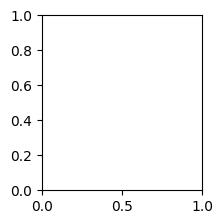

In [ ]:
n = 5

plt.figure(figsize=(12,5))

for i in range(n):

    plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].squeeze(),
               cmap="gray")
    plt.axis("off")

    plt.subplot(2,n,i+1+n)
    plt.imshow(pred[i].squeeze(),
               cmap="gray")
    plt.axis("off")

plt.show()

** Guardar modelo

In [ ]:
cae.save_model("covid_cae.h5")